In [5]:
# attempt 6
import math
import random
import pandas as pd
import numpy as np   
import matplotlib.pyplot as plt
from collections import Counter


# decrease computation time
def df_to_numpy(df, y="label"):
    X_df = df.drop(columns=[y])
    feature_types = []
    X = []

    for col in X_df.columns:
        if "_num" in col:
            feature_types.append("num")
            X.append(X_df[col].astype(float).to_numpy())
        else:
            feature_types.append("cat")
            X.append(X_df[col].astype(str).to_numpy())

    X = np.column_stack(X)
    y_vals = df[y].to_numpy()
    return X, y_vals, feature_types


def entropy_numpy(y):
    values, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs + 1e-12))


class Node:
    def __init__(self, attribute=None, label=None, majority=None,
                 threshold=None, is_cat=False):
        self.attribute = attribute
        self.label = label
        self.majority = majority
        self.threshold = threshold
        self.is_cat = is_cat
        self.children = {}


# minimum gain split for num and cat
def best_numeric_split_numpy(X, y, j):
    values = np.unique(X[:, j].astype(float))
    if len(values) <= 1:
        return None, -1
    values.sort()
    parent_entropy = entropy_numpy(y)
    best_gain = -1
    best_threshold = None

    for i in range(len(values) - 1):
        threshold = (values[i] + values[i + 1]) / 2

        left = X[:, j].astype(float) <= threshold
        right = ~left

        if np.sum(left) == 0 or np.sum(right) == 0:
            continue

        y_l, y_r = y[left], y[right]

        gain = parent_entropy - (
            (len(y_l) / len(y)) * entropy_numpy(y_l) +
            (len(y_r) / len(y)) * entropy_numpy(y_r)
        )

        if gain > best_gain:
            best_gain = gain
            best_threshold = threshold

    return best_threshold, best_gain

def best_categorical_split_numpy(X, y, j):
    values = np.unique(X[:, j])

    if len(values) <= 1:
        return None, -1

    parent_entropy = entropy_numpy(y)

    best_gain = -1
    best_val = None

    for val in values:
        left = X[:, j] == val
        right = ~left

        if np.sum(left) == 0 or np.sum(right) == 0:
            continue

        y_l, y_r = y[left], y[right]

        gain = parent_entropy - (
            (len(y_l) / len(y)) * entropy_numpy(y_l) +
            (len(y_r) / len(y)) * entropy_numpy(y_r)
        )

        if gain > best_gain:
            best_gain = gain
            best_val = val

    return best_val, best_gain

# edit old decision tree for max depth, minimum gain, and computational efficiency ie convert to np
def decision_tree_numpy(X, y, feature_types,
                        depth=0, max_depth=10,
                        max_features=None, min_gain=0):

    if len(np.unique(y)) == 1:
        return Node(label=y[0])

    if depth >= max_depth:
        return Node(label=Counter(y).most_common(1)[0][0])

    n_features = X.shape[1]

    if max_features is None:
        max_features = int(np.sqrt(n_features))

    feature_indices = np.random.choice(n_features, max_features, replace=False)

    best_gain = -1
    best_feature = None
    best_split = None
    best_masks = None
    best_is_cat = False

    for j in feature_indices:

        if feature_types[j] == "num":
            split, gain = best_numeric_split_numpy(X, y, j)

            if split is None:
                continue

            left = X[:, j].astype(float) <= split
            right = ~left
            is_cat = False

        else:
            split, gain = best_categorical_split_numpy(X, y, j)

            if split is None:
                continue

            left = X[:, j] == split
            right = ~left
            is_cat = True

        if gain > best_gain:
            best_gain = gain
            best_feature = j
            best_split = split
            best_masks = (left, right)
            best_is_cat = is_cat
    # stopping criterion
    if best_gain <= min_gain or best_feature is None:
        return Node(label=Counter(y).most_common(1)[0][0])

    node = Node(
        attribute=best_feature,
        threshold=best_split,
        majority=Counter(y).most_common(1)[0][0],
        is_cat=best_is_cat
    )

    left_mask, right_mask = best_masks

    node.children["left"] = decision_tree_numpy(
        X[left_mask], y[left_mask],
        feature_types,
        depth + 1, max_depth,
        max_features, min_gain
    )

    node.children["right"] = decision_tree_numpy(
        X[right_mask], y[right_mask],
        feature_types,
        depth + 1, max_depth,
        max_features, min_gain
    )

    return node

# 
def predict_tree(node, x):
    if node.label is not None:
        return node.label

    if node.is_cat:
        if x[node.attribute] == node.threshold:
            return predict_tree(node.children["left"], x)
        else:
            return predict_tree(node.children["right"], x)
    else:
        if float(x[node.attribute]) <= node.threshold:
            return predict_tree(node.children["left"], x)
        else:
            return predict_tree(node.children["right"], x)

class RainForest:
    def __init__(self, num_trees=10, max_depth=10, min_gain=0):
        self.num_trees = num_trees
        self.max_depth = max_depth
        self.min_gain = min_gain
        self.trees = []
        self.feature_types = None

    def fit(self, X, y, feature_types):
        self.trees = []
        self.feature_types = feature_types

        n = len(X)

        for _ in range(self.num_trees):
            idx = np.random.choice(n, n, replace=True)
            X_s, y_s = X[idx], y[idx]

            tree = decision_tree_numpy(
                X_s, y_s,
                feature_types,
                max_depth=self.max_depth,
                min_gain=self.min_gain
            )

            self.trees.append(tree)

    def predict(self, X):
        preds = []

        for tree in self.trees:
            preds.append([predict_tree(tree, x) for x in X])

        preds = np.array(preds).T

        return [Counter(row).most_common(1)[0][0] for row in preds]
    
def stratified_k_fold(df, k=5, y="label"):
    folds = [[] for _ in range(k)]

    classes = df[y].unique()
    class_subsets = {}

    for c in classes:
        subset = df[df[y] == c].sample(frac=1).reset_index(drop=True)
        class_subsets[c] = subset

    for c in classes:
        subset = class_subsets[c]
        for i in range(len(subset)):
            folds[i % k].append(subset.iloc[i])

    folds = [pd.DataFrame(fold).reset_index(drop=True) for fold in folds]

    return folds


#new confusion matric
def confusion_matrix(preds, labels, positive_class):
    TP = FP = TN = FN = 0

    for i in range(len(labels)):
        if labels[i] == positive_class and preds[i] == positive_class:
            TP += 1
        elif labels[i] != positive_class and preds[i] == positive_class:
            FP += 1
        elif labels[i] != positive_class and preds[i] != positive_class:
            TN += 1
        else:
            FN += 1

    return TP, FP, TN, FN

def accuracy(TP, FP, TN, FN):
    return (TP + TN) / (TP + FP + TN + FN + 1e-12)

def precision(TP, FP):
    return TP / (TP + FP + 1e-12)

def recall(TP, FN):
    return TP / (TP + FN + 1e-12)

def f1(TP, FP, FN):
    p = precision(TP, FP)
    r = recall(TP, FN)
    return 2 * p * r / (p + r + 1e-12)


def evaluate_random_forest(df, ntree_values, k=5, max_depth=10, y="label", min_gain=0):

    folds = stratified_k_fold(df, k, y)

    results = {
        "accuracy": [],
        "precision": [],
        "recall": [],
        "f1": []
    }

    positive_class = Counter(df[y]).most_common(1)[0][0]

    for ntree in ntree_values:

        acc_list, prec_list, rec_list, f1_list = [], [], [], []

        for i in range(k):

            test_df = folds[i]
            train_df = pd.concat([folds[j] for j in range(k) if j != i])

            X_train, y_train, feature_types = df_to_numpy(train_df, y)
            X_test, y_test, _ = df_to_numpy(test_df, y)

            rf = RainForest(num_trees=ntree, max_depth=max_depth, min_gain=min_gain)
            rf.fit(X_train, y_train, feature_types)

            preds = rf.predict(X_test)

            TP, FP, TN, FN = confusion_matrix(preds, y_test, positive_class)

            acc_list.append(accuracy(TP, FP, TN, FN))
            prec_list.append(precision(TP, FP))
            rec_list.append(recall(TP, FN))
            f1_list.append(f1(TP, FP, FN))

        results["accuracy"].append(np.mean(acc_list))
        results["precision"].append(np.mean(prec_list))
        results["recall"].append(np.mean(rec_list))
        results["f1"].append(np.mean(f1_list))

    return results

def print_results(ntree_values, results):
    for i in range(len(ntree_values)):
        print(f"ntree: {ntree_values[i]:<10}"
              f"Accuracy: {results['accuracy'][i]:.4f} "
              f"Precision: {results['precision'][i]:.4f} "
              f"Recall: {results['recall'][i]:.4f} "
              f"F1 Score: {results['f1'][i]:.4f} ")

def plot_results(ntree_values, results, title_prefix="Dataset"):
    metrics = ["accuracy", "precision", "recall", "f1"]

    for metric in metrics:
        plt.figure()
        plt.plot(ntree_values, results[metric], marker='o')
        plt.xlabel("Number of Trees")
        plt.ylabel(metric.capitalize())
        plt.title(f"{title_prefix} - {metric.capitalize()} vs Number of Trees")
        plt.grid()
        plt.show()

In [2]:
rice = "../../res/rice.csv"
credit = "../../res/credit_approval.csv"
parkinsons = "../../res/parkinsons.csv"
parkinsons_df = pd.read_csv(parkinsons)
credit_df = pd.read_csv(credit)
rice_df = pd.read_csv(rice)
from sklearn import datasets
digits_dataset_X, digits_dataset_y = datasets.load_digits(return_X_y=True)
digits_df = pd.DataFrame(digits_dataset_X, columns=[f"pixel_{i}" for i in range(64)])
digits_df['label'] = digits_dataset_y

ntree: 1         Accuracy: 0.9331Precision: 0.6887Recall: 0.6711F1 Score: 0.6724
ntree: 5         Accuracy: 0.9655Precision: 0.8503Recall: 0.8140F1 Score: 0.8274
ntree: 10        Accuracy: 0.9671Precision: 0.8443Recall: 0.8365F1 Score: 0.8360
ntree: 20        Accuracy: 0.9772Precision: 0.9143Recall: 0.8640F1 Score: 0.8859
ntree: 30        Accuracy: 0.9766Precision: 0.9047Recall: 0.8635F1 Score: 0.8820
ntree: 40        Accuracy: 0.9828Precision: 0.9349Recall: 0.8965F1 Score: 0.9131
ntree: 50        Accuracy: 0.9811Precision: 0.9430Recall: 0.8696F1 Score: 0.9032


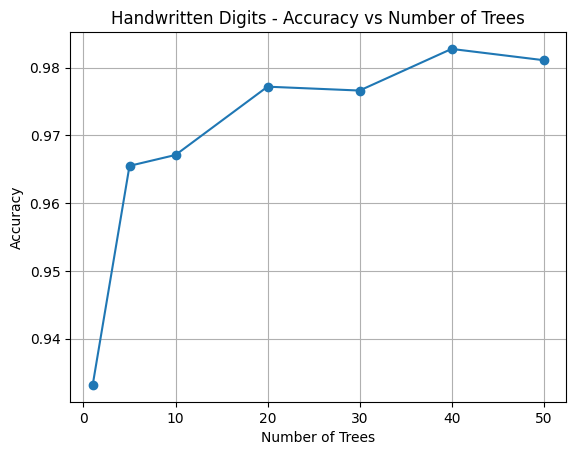

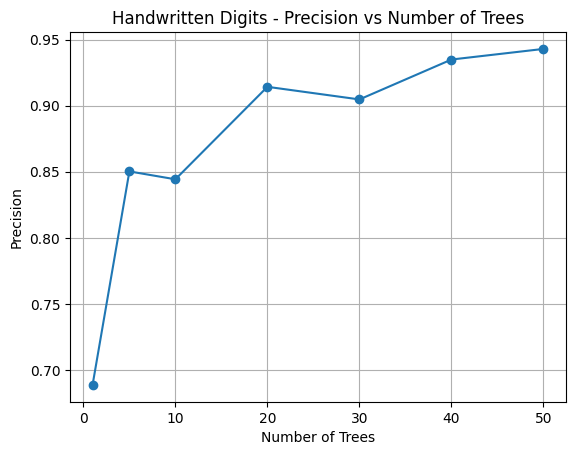

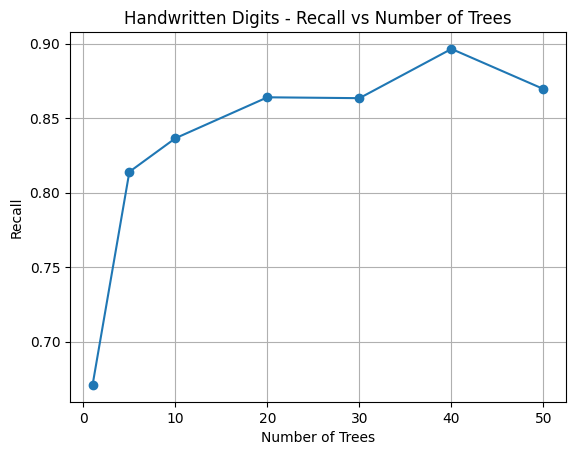

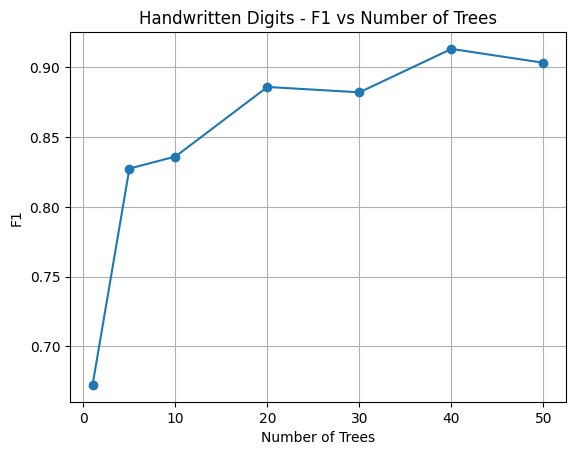

In [3]:
ntree_values = [1, 5, 10, 20, 30, 40, 50]
# 0.00000001
results = evaluate_random_forest(digits_df, ntree_values, k=10, max_depth=13, y="label", min_gain=0.0000001)
print_results(ntree_values, results)
plot_results(ntree_values, results, title_prefix="Handwritten Digits")

ntree: 1         Accuracy: 0.9293 Precision: 0.6823 Recall: 0.6105 F1 Score: 0.6362 
ntree: 5         Accuracy: 0.9661 Precision: 0.8367 Recall: 0.8360 F1 Score: 0.8311 
ntree: 10        Accuracy: 0.9761 Precision: 0.8941 Recall: 0.8749 F1 Score: 0.8829 
ntree: 20        Accuracy: 0.9772 Precision: 0.8979 Recall: 0.8801 F1 Score: 0.8860 
ntree: 30        Accuracy: 0.9755 Precision: 0.8934 Recall: 0.8690 F1 Score: 0.8792 
ntree: 40        Accuracy: 0.9805 Precision: 0.9299 Recall: 0.8795 F1 Score: 0.9015 
ntree: 50        Accuracy: 0.9822 Precision: 0.9451 Recall: 0.8795 F1 Score: 0.9087 


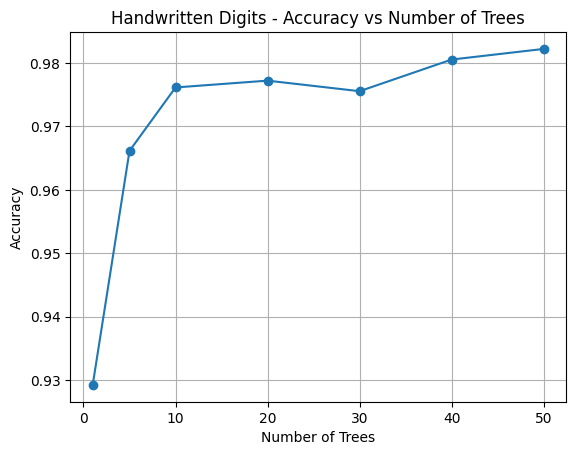

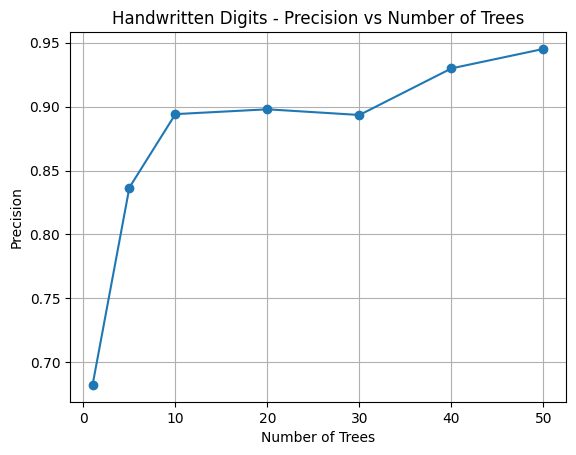

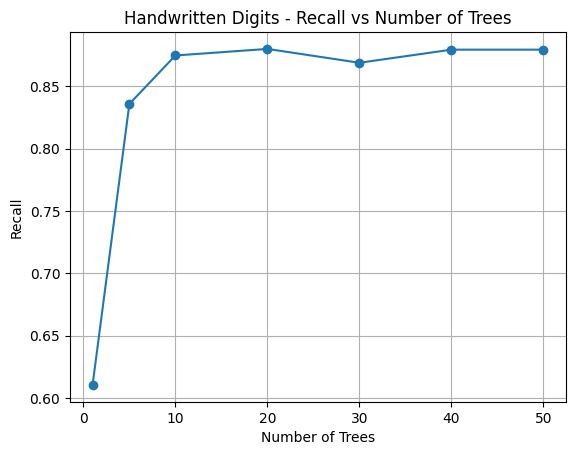

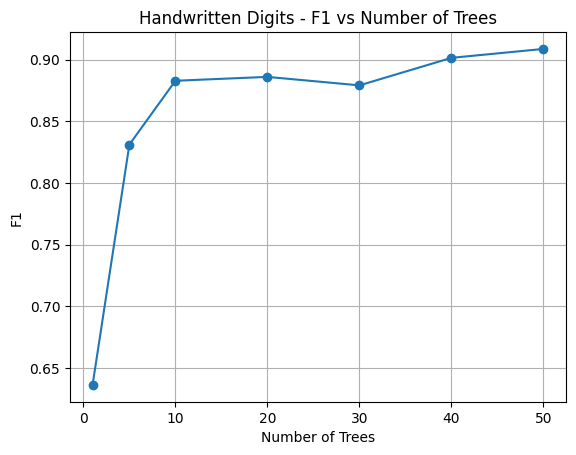

In [6]:
ntree_values = [1, 5, 10, 20, 30, 40, 50]
# 0.00000001
results = evaluate_random_forest(digits_df, ntree_values, k=10, max_depth=13, y="label", min_gain=0.0001)
print_results(ntree_values, results)
plot_results(ntree_values, results, title_prefix="Handwritten Digits")

In [ ]:
ntree_values = [1, 5, 10, 20, 30, 40, 50]
# 0.00000001
results = evaluate_random_forest(rice_df, ntree_values, k=10, max_depth=11, y="label", min_gain=0.0001)
print_results(ntree_values, results)
plot_results(ntree_values, results, title_prefix="Rice Dataset")